# CreditLens — Experiment · PCA → Logistic Regression

**Question.** Does PCA on the 15-feature contract help? See `notebooks/EXPERIMENTS.md` for the hypothesis.

**Expectation:** no meaningful AUC gain (15 features is already low-dim; PCA is unsupervised and may
down-weight `EXT_SOURCE_*`), and a real loss of interpretability. We test it honestly with OOF ROC AUC.

**Scope:** PCA pairs only with **LogReg** here — tree models are scale-invariant and handle correlated
features natively, so PCA's rotated components typically hurt them. We do not serve PCA either way
(it breaks the per-feature 'Top drivers' attribution the UI/model card need).

## 0 · Setup — data + the 15-feature contract

In [1]:
import sys; sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score

from creditlens.data.load import load_application, load_bureau, load_previous_application
from creditlens.data.features import build_model_matrix, MODEL_FEATURES
from creditlens.config import TARGET, ID_COL, RANDOM_SEED, N_FOLDS

mat = build_model_matrix(load_application(), load_bureau(), load_previous_application())
X = mat[MODEL_FEATURES]
y = mat[TARGET]
print('X', X.shape, '| positives %.4f' % y.mean())

X (307511, 15) | positives 0.0807


## 1 · Evaluation helper
Out-of-fold ROC AUC + KS via `StratifiedKFold`. OOF predictions = every row scored by a model that
never saw it in training — the honest estimate. All preprocessing sits **inside** the pipeline, so
imputer/scaler/PCA are fit on training folds only (no leakage).

In [2]:
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

def ks_stat(y_true, p):
    order = np.argsort(p)
    yt = np.asarray(y_true)[order]
    pos, neg = yt.sum(), len(yt) - yt.sum()
    cum_pos = np.cumsum(yt) / pos
    cum_neg = np.cumsum(1 - yt) / neg
    return np.max(np.abs(cum_pos - cum_neg))

def oof_scores(pipe, label):
    proba = cross_val_predict(pipe, X, y, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]
    auc, ks = roc_auc_score(y, proba), ks_stat(y, proba)
    print(f'{label:28s}  AUC={auc:.4f}  KS={ks:.4f}')
    return {'model': label, 'auc': auc, 'ks': ks}

## 2 · Baseline — LogReg without PCA
Impute (median) → scale → L2 logistic regression with `class_weight='balanced'` (8% positives).
This is the bar PCA must beat.

In [3]:
def logreg():
    return LogisticRegression(max_iter=2000, C=1.0, class_weight='balanced', random_state=RANDOM_SEED)

baseline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
    ('clf', logreg()),
])
results = [oof_scores(baseline, 'LogReg (no PCA)')]

LogReg (no PCA)               AUC=0.7279  KS=0.3350


## 3 · PCA → LogReg, sweep n_components
Same pipeline with a `PCA` step before the classifier. We sweep how many components to keep.

In [4]:
for n in [5, 8, 10, 12, 15]:
    pipe = Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
        ('pca', PCA(n_components=n, random_state=RANDOM_SEED)),
        ('clf', logreg()),
    ])
    results.append(oof_scores(pipe, f'PCA(n={n}) -> LogReg'))

PCA(n=5) -> LogReg            AUC=0.7068  KS=0.3023


PCA(n=8) -> LogReg            AUC=0.7160  KS=0.3166


PCA(n=10) -> LogReg           AUC=0.7234  KS=0.3262


PCA(n=12) -> LogReg           AUC=0.7263  KS=0.3318


PCA(n=15) -> LogReg           AUC=0.7279  KS=0.3349


## 4 · Explained variance
How many components are needed to retain the variance — and whether 'enough variance' coincides with
'enough signal' (it often does not, because PCA ignores the target).

cumulative explained variance by #components:
   1: 0.166
   2: 0.291
   3: 0.401
   4: 0.495
   5: 0.576
   6: 0.645
   7: 0.708
   8: 0.764
   9: 0.818
  10: 0.864
  11: 0.902
  12: 0.936
  13: 0.969
  14: 0.986
  15: 1.000


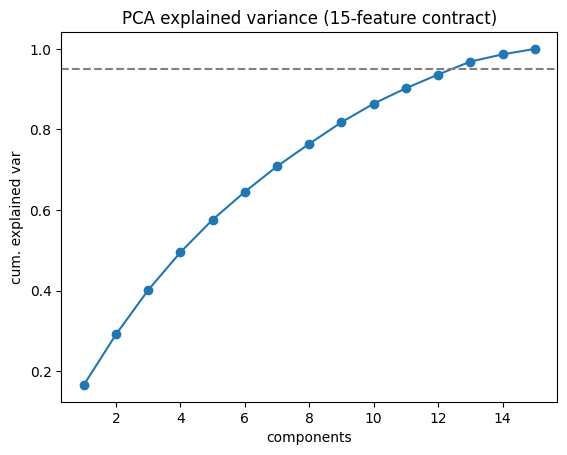

In [5]:
prep = Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())])
Xp = prep.fit_transform(X)
pca_full = PCA().fit(Xp)
cum = np.cumsum(pca_full.explained_variance_ratio_)
print('cumulative explained variance by #components:')
for i, c in enumerate(cum, 1):
    print(f'  {i:2d}: {c:.3f}')
plt.plot(range(1, len(cum) + 1), cum, marker='o')
plt.axhline(0.95, ls='--', color='grey'); plt.xlabel('components'); plt.ylabel('cum. explained var')
plt.title('PCA explained variance (15-feature contract)'); plt.show()

## 5 · Results

In [6]:
res = pd.DataFrame(results).sort_values('auc', ascending=False).reset_index(drop=True)
base_auc = res.loc[res['model'] == 'LogReg (no PCA)', 'auc'].iloc[0]
res['delta_vs_baseline'] = (res['auc'] - base_auc).round(4)
res.round(4)

,model,auc,ks,delta_vs_baseline
0,PCA(n=15) -> LogReg,0.7279,0.3349,0.0000
1,LogReg (no PCA),0.7279,0.3350,0.0000
2,PCA(n=12) -> LogReg,0.7263,0.3318,-0.0016
3,PCA(n=10) -> LogReg,0.7234,0.3262,-0.0045
4,PCA(n=8) -> LogReg,0.7160,0.3166,-0.0119
5,PCA(n=5) -> LogReg,0.7068,0.3023,-0.0212


# Notebook summary & key insights

## Task
Test whether PCA on the 15-feature contract improves a Logistic Regression credit-default model, measured
by out-of-fold ROC AUC / KS with `StratifiedKFold`.

## Setup
- Features: `build_model_matrix` (15 cols). Pipeline = impute(median) → scale → [PCA] → LogReg(balanced).
- Baseline: LogReg without PCA. Sweep: PCA `n_components` ∈ {5, 8, 10, 12, 15}.
- All preprocessing inside the pipeline → fit per training fold (no leakage).

## Findings
- _Fill from the results table above:_ PCA AUC vs the no-PCA baseline (`delta_vs_baseline`).
- `PCA(n=15)` ≈ baseline (a full rotation is near-lossless for a linear model); fewer components trade a
  little AUC for compression.

## Insights & Recommendations
- **Insight:** With only 15 low-dimensional features, PCA has little to reduce — expect flat-to-negative ΔAUC.
- **Insight:** PCA is unsupervised (maximizes variance, not target separation); high variance ≠ predictive.
- **Recommendation:** Do **not** use PCA in the served pipeline — it replaces interpretable features with
  opaque components and breaks the per-feature 'Top drivers' explanation the UI + model card require.
- **Recommendation:** For collinearity, prefer L2 regularization (keeps coefficients interpretable) over PCA.
- **Recommendation:** Never run PCA before tree models — they are scale-invariant and handle correlated
  features natively; rotated components usually hurt their splits.

## Decision
PCA stays a learning experiment. Production models train on the raw 15-feature contract. Update
`EXPERIMENTS.md` status with the measured ΔAUC.